# k-means y derivados: k-medians, k-medoids, fuzzy C-means y Canopy

> Cómo agrupar datos en $k$ grupos alrededor de centros: el algoritmo k-means, cómo inicializarlo y elegir $k$, sus supuestos y límites, y las variantes que los relajan (k-medians, k-medoids, fuzzy C-means) o aceleran el proceso con muchos datos (mini-batch, Canopy).
>
> **Requisitos previos:** [Distancias y similitud](../03-preparacion-datos/05-distancias-y-similitud.ipynb) · **Relacionado:** [Clustering jerárquico](04-clustering-jerarquico.ipynb), [Clustering por densidad](06-clustering-densidad.ipynb)

## 1. Idea clave

**k-means** divide $n$ observaciones en $k$ grupos, cada uno representado por su **centroide** (la media de sus puntos), de forma que cada punto pertenezca al grupo del centroide más cercano. Es el algoritmo de agrupamiento más usado porque es simple, rápido y escala a millones de datos. Además, los centroides resumen cada grupo y permiten asignar datos nuevos.

A cambio, hace supuestos fuertes: hay que **fijar $k$** de antemano, usa distancia **euclídea** (así que necesita variables numéricas y escaladas) y funciona bien con grupos **compactos, convexos y de tamaño parecido**. Con grupos alargados, anidados o de densidades muy distintas, falla.

Sus variantes corrigen parte de estos problemas:
- **k-medians** y **k-medoids**: más robustos frente a atípicos; k-medoids admite cualquier distancia.
- **Fuzzy C-means**: pertenencia gradual a varios grupos.
- **Mini-batch k-means** y **Canopy**: aceleran el cálculo con conjuntos grandes.

## 2. Conceptos importantes

### 2.1. El objetivo y el algoritmo

k-means minimiza la **inercia** (o suma de cuadrados dentro de los grupos, SSE):

$$
J = \sum_{j=1}^{k} \sum_{\mathbf{x} \in C_j} \lVert \mathbf{x} - \boldsymbol{\mu}_j \rVert^2
$$

donde $C_j$ es el grupo $j$ y $\boldsymbol{\mu}_j$ su centroide. El algoritmo de Lloyd alterna dos pasos hasta que las asignaciones dejan de cambiar:

1. **Asignación**: cada punto va al centroide más cercano.
2. **Actualización**: cada centroide pasa a ser la media de sus puntos.

Cada paso reduce (o mantiene) $J$, así que el algoritmo **converge**, pero a un **mínimo local**: el resultado depende de los centroides iniciales.

### 2.2. Inicialización

- **Aleatoria**: $k$ puntos al azar. Puede caer en mínimos locales malos, por ejemplo con dos centroides en el mismo grupo real.
- **k-means++**: elige el primer centroide al azar y cada siguiente con probabilidad proporcional al cuadrado de su distancia al centroide más cercano ya elegido. Así los centroides iniciales quedan repartidos. Es la opción por defecto en scikit-learn.
- **Varias ejecuciones** (`n_init`): repetir con distintas semillas y quedarse con la de menor inercia.

### 2.3. Cómo elegir $k$

- **Método del codo**: dibujar la inercia frente a $k$. Siempre baja al aumentar $k$ (con $k = n$ es 0), así que se busca el "codo" a partir del cual la mejora es pequeña. A menudo el codo es ambiguo.
- **Coeficiente de silueta**: para cada punto $i$, con $a(i)$ la distancia media a los puntos de su grupo y $b(i)$ la distancia media a los del grupo vecino más cercano,

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}} \in [-1, 1]
$$

  Cercano a 1: bien agrupado. Cercano a 0: en la frontera. Negativo: probablemente en el grupo equivocado. Se elige el $k$ con la silueta media más alta.
- **Conocimiento del dominio**: cuántos segmentos son útiles o interpretables. Las métricas orientan, pero no deciden solas.

### 2.4. Supuestos de k-means

- Grupos **convexos y aproximadamente esféricos**: la frontera entre dos grupos es la mediatriz entre sus centroides.
- Tamaños y dispersiones **parecidos**: un grupo muy disperso "roba" puntos a otro compacto vecino.
- Distancia **euclídea**: necesita variables numéricas en escalas comparables. La media no tiene sentido con categóricas.
- **Sensible a atípicos**: la media se desplaza hacia ellos.

### 2.5. Variantes

| Variante | Centro | Distancia | Qué aporta |
|---|---|---|---|
| **k-medians** | Mediana de cada coordenada | Manhattan | Más robusto frente a atípicos |
| **k-medoids** (PAM) | Un **punto real** del grupo (el *medoide*), el que minimiza la suma de distancias al resto | **Cualquiera** | Robusto; centros interpretables; admite Jaccard, Gower… |
| **Fuzzy C-means** | Media ponderada por la pertenencia | Euclídea | Pertenencia gradual $u_{ij} \in [0, 1]$ a cada grupo |
| **Mini-batch k-means** | Media, actualizada con muestras pequeñas | Euclídea | Mucho más rápido con muchos datos |
| **Bisecting k-means** | Media | Euclídea | Estrategia divisiva (ver [clustering jerárquico](04-clustering-jerarquico.ipynb)) |

En **fuzzy C-means**, la pertenencia del punto $\mathbf{x}_i$ al grupo $j$ depende de su distancia relativa a todos los centros $\mathbf{c}_1, \dots, \mathbf{c}_k$:

$$
u_{ij} = \left( \sum_{l=1}^{k} \left( \frac{\lVert \mathbf{x}_i - \mathbf{c}_j \rVert}{\lVert \mathbf{x}_i - \mathbf{c}_l \rVert} \right)^{\frac{2}{m-1}} \right)^{-1}, \qquad \sum_{j} u_{ij} = 1
$$

donde $m > 1$ es el **grado de difusión** (*fuzzifier*): con $m \to 1$ se parece a k-means, y con $m$ grande todas las pertenencias tienden a $1/k$. Lo habitual es $m = 2$.

### 2.6. Canopy: agrupar antes de agrupar

El algoritmo **Canopy** es un paso previo (*preclustering*) para conjuntos muy grandes. Con una distancia **barata** y dos umbrales $T_1 > T_2$:

1. Se elige un punto al azar como centro de un nuevo *canopy*.
2. Los puntos a menos de $T_1$ entran en ese canopy. Un punto puede estar en varios.
3. Los puntos a menos de $T_2$ se retiran: ya no pueden ser centro de otro canopy.
4. Se repite hasta que no quedan puntos.

Después, el algoritmo caro (k-means, jerárquico) solo calcula distancias entre puntos que comparten canopy.

## 3. Código

Usamos grupos sintéticos (`make_blobs`) con 4 grupos, dos de ellos cercanos, para ver el algoritmo y la elección de $k$. Para datos reales, **wine** (178 vinos, 3 variedades, 13 medidas químicas; repositorio UCI). Las etiquetas verdaderas solo se usan para evaluar, con el índice de Rand ajustado (ARI: 1 = perfecto, ≈ 0 = azar).

### 3.1. k-means en acción

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import load_wine, make_blobs, make_circles, make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
centros_reales = [[-6, 6], [-3, 5], [4, -2], [6, 6]]  # los dos primeros, cercanos
X, y = make_blobs(n_samples=600, centers=centros_reales, cluster_std=[1.2, 1.2, 1.5, 1.0], random_state=42)

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X)
print(f"Inercia: {kmeans.inertia_:.0f} | iteraciones: {kmeans.n_iter_} | ARI: {adjusted_rand_score(y, kmeans.labels_):.2f}")

# Asignar puntos nuevos: al centroide más cercano
nuevos = np.array([[-4.5, 5.5], [5, 2]])
print(f"Grupo asignado a dos puntos nuevos: {kmeans.predict(nuevos)}")

Inercia: 1668 | iteraciones: 4 | ARI: 0.87
Grupo asignado a dos puntos nuevos: [3 2]


### 3.2. Inicialización: mínimos locales

Ejecutamos k-means con inicialización **aleatoria** y **una sola** ejecución, con 8 semillas distintas:

In [3]:
inercias = {semilla: KMeans(n_clusters=4, init="random", n_init=1, random_state=semilla).fit(X).inertia_
            for semilla in range(8)}
print("Inicialización aleatoria, 1 ejecución:", {s: round(i) for s, i in inercias.items()})
print(f"k-means++ con 10 ejecuciones:         {KMeans(n_clusters=4, n_init=10, random_state=42).fit(X).inertia_:.0f}")

Inicialización aleatoria, 1 ejecución: {0: 1668, 1: 6458, 2: 6458, 3: 1668, 4: 6457, 5: 1668, 6: 2327, 7: 1668}
k-means++ con 10 ejecuciones:         1668


Con una sola ejecución aleatoria, la mitad de las semillas acaba en un mínimo local con una inercia casi 4 veces mayor que la óptima (≈ 6.458 frente a ≈ 1.668): dos centroides comparten un grupo real y otros dos grupos se fusionan. k-means++ con varias ejecuciones evita este problema.

### 3.3. Elegir $k$: codo y silueta

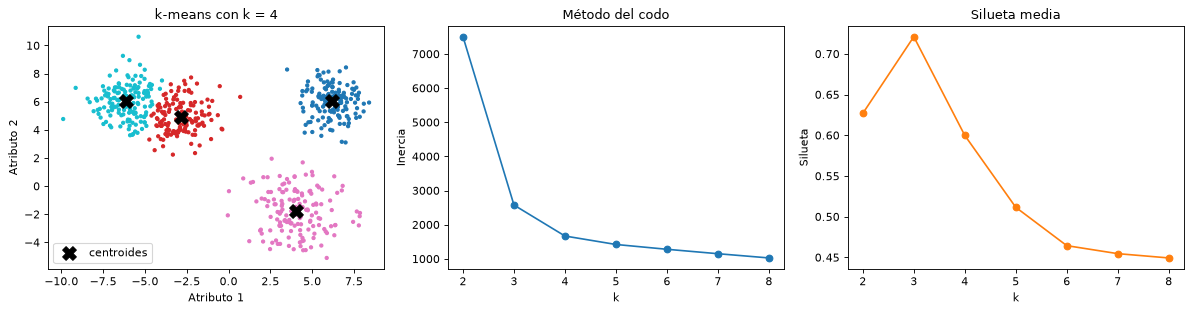

,inercia,silueta,ARI (usa las etiquetas reales)
k,,,
2,7504.003,0.627,0.499
3,2574.225,0.721,0.713
4,1667.785,0.600,0.869
5,1420.168,0.511,0.778
6,1279.402,0.464,0.714
7,1149.728,0.455,0.679
8,1025.933,0.449,0.625


In [4]:
valores_k = range(2, 9)
modelos_k = {k: KMeans(n_clusters=k, n_init=10, random_state=42).fit(X) for k in valores_k}
eleccion = pd.DataFrame({
    "inercia": [modelos_k[k].inertia_ for k in valores_k],
    "silueta": [silhouette_score(X, modelos_k[k].labels_) for k in valores_k],
    "ARI (usa las etiquetas reales)": [adjusted_rand_score(y, modelos_k[k].labels_) for k in valores_k],
}, index=pd.Index(valores_k, name="k"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=80)
axes[0].scatter(X[:, 0], X[:, 1], c=modelos_k[4].labels_, cmap="tab10", s=8)
axes[0].scatter(*modelos_k[4].cluster_centers_.T, c="black", marker="X", s=150, label="centroides")
axes[0].set_title("k-means con k = 4")
axes[0].set_xlabel("Atributo 1")
axes[0].set_ylabel("Atributo 2")
axes[0].legend(loc="lower left")
axes[1].plot(eleccion.index, eleccion["inercia"], marker="o")
axes[1].set_title("Método del codo")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inercia")
axes[2].plot(eleccion.index, eleccion["silueta"], marker="o", color="tab:orange")
axes[2].set_title("Silueta media")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Silueta")
plt.tight_layout()
plt.show()

eleccion.round(3)

- El **codo** es ambiguo: la inercia cae mucho hasta $k = 3$, algo menos hasta $k = 4$ y después baja poco a poco. Se podría defender 3 o 4.
- La **silueta** es máxima con $k = 3$, aunque hay 4 grupos reales. Los dos grupos cercanos de arriba a la izquierda se separan peor que el resto, y la silueta "premia" fusionarlos.
- Con las etiquetas reales, el mejor ARI está en $k = 4$.

Las métricas internas miden lo **separados** que están los grupos, no si son los "correctos". Si el dominio sugiere que dos segmentos parecidos son distintos (por ejemplo, dos tipos de cliente con hábitos cercanos), $k = 4$ puede ser la mejor elección aunque la silueta diga lo contrario.

### 3.4. Cuándo falla k-means

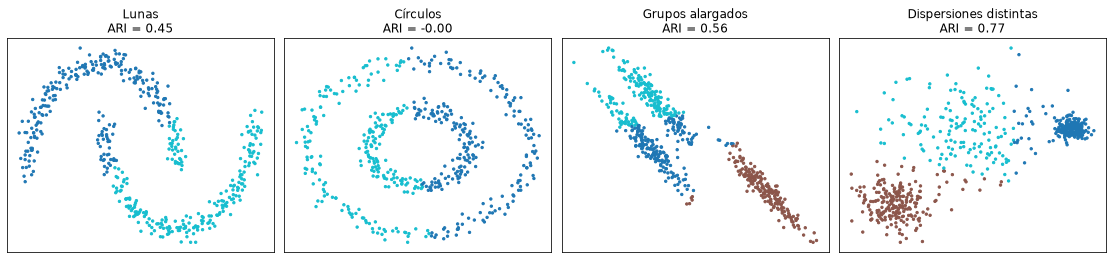

In [5]:
rng = np.random.default_rng(42)
X_aniso, y_aniso = make_blobs(n_samples=600, centers=3, random_state=170)
X_aniso = X_aniso @ np.array([[0.6, -0.64], [-0.41, 0.85]])  # estirar los grupos
casos = {
    "Lunas": make_moons(n_samples=500, noise=0.06, random_state=42),
    "Círculos": make_circles(n_samples=500, factor=0.45, noise=0.05, random_state=42),
    "Grupos alargados": (X_aniso, y_aniso),
    "Dispersiones distintas": make_blobs(n_samples=600, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=170),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), dpi=70)
for ax, (nombre, (X_caso, y_caso)) in zip(axes, casos.items()):
    X_caso = StandardScaler().fit_transform(X_caso)
    etiquetas = KMeans(n_clusters=len(np.unique(y_caso)), n_init=10, random_state=42).fit_predict(X_caso)
    ax.scatter(X_caso[:, 0], X_caso[:, 1], c=etiquetas, cmap="tab10", s=6)
    ax.set_title(f"{nombre}\nARI = {adjusted_rand_score(y_caso, etiquetas):.2f}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

- En las **lunas** y los **círculos**, k-means corta las formas con una recta, porque sus fronteras son siempre lineales. Para estas formas hacen falta el [enlace simple](04-clustering-jerarquico.ipynb) o los [métodos por densidad](06-clustering-densidad.ipynb).
- Con **grupos alargados**, la distancia euclídea a la media no respeta la forma, y parte de un grupo acaba en el vecino.
- Con **dispersiones distintas**, el grupo disperso pierde sus puntos exteriores a favor de los compactos.

### 3.5. Datos reales: la importancia de escalar

In [6]:
X_wine, y_wine = load_wine(return_X_y=True)

for nombre, datos in [("sin escalar", X_wine), ("estandarizado", StandardScaler().fit_transform(X_wine))]:
    etiquetas = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(datos)
    print(f"wine {nombre:14s} ARI = {adjusted_rand_score(y_wine, etiquetas):.2f}")

wine sin escalar    ARI = 0.37
wine estandarizado  ARI = 0.90


Sin escalar, la prolina (valores de cientos) decide casi sola los grupos. Al estandarizar, k-means recupera las tres variedades con bastante precisión (ver [distancias y escalado](../03-preparacion-datos/05-distancias-y-similitud.ipynb)).

### 3.6. k-medoids: robustez frente a atípicos

scikit-learn no incluye k-medoids. Una versión sencilla alterna asignar cada punto al medoide más cercano y elegir como nuevo medoide el punto del grupo con menor suma de distancias al resto:

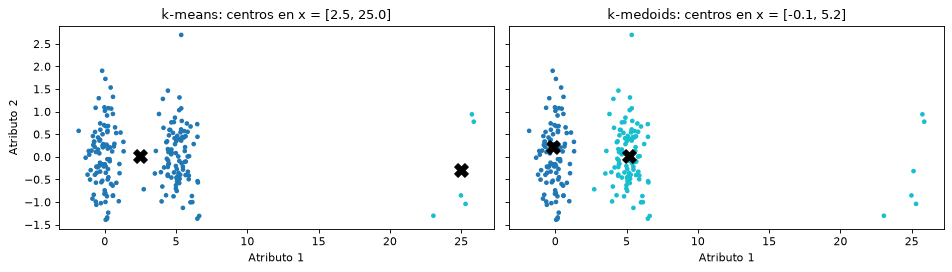

In [7]:
def kmedoids(X, k, metric="euclidean", n_iter=50, seed=42):
    """k-medoids por alternancia: los centros son siempre puntos reales del conjunto."""
    D = cdist(X, X, metric=metric)
    medoides = np.random.default_rng(seed).choice(len(X), size=k, replace=False)
    for _ in range(n_iter):
        etiquetas = D[:, medoides].argmin(axis=1)
        nuevos = np.array([np.flatnonzero(etiquetas == j)[D[np.ix_(etiquetas == j, etiquetas == j)].sum(axis=1).argmin()]
                           for j in range(k)])
        if np.array_equal(np.sort(nuevos), np.sort(medoides)):
            break
        medoides = nuevos
    return etiquetas, medoides

# Dos grupos compactos y unos pocos atípicos muy lejanos a la derecha
X_at, y_at = make_blobs(n_samples=200, centers=[[0, 0], [5, 0]], cluster_std=0.7, random_state=42)
atipicos = rng.normal(loc=[25, 0], scale=1.0, size=(6, 2))
X_at = np.vstack([X_at, atipicos])

km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_at)
etiq_med, idx_med = kmedoids(X_at, k=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), dpi=80, sharey=True)
for ax, (nombre, etiquetas, centros) in zip(axes, [("k-means", km.labels_, km.cluster_centers_),
                                                   ("k-medoids", etiq_med, X_at[idx_med])]):
    ax.scatter(X_at[:, 0], X_at[:, 1], c=etiquetas, cmap="tab10", s=10)
    ax.scatter(*centros.T, c="black", marker="X", s=150)
    ax.set_title(f"{nombre}: centros en x = {np.round(np.sort(centros[:, 0]), 1).tolist()}")
    ax.set_xlabel("Atributo 1")
axes[0].set_ylabel("Atributo 2")
plt.tight_layout()
plt.show()

Con solo 6 atípicos (un 3 % de los datos), k-means dedica uno de sus dos centroides a ellos y **fusiona los dos grupos reales** en el otro. k-medoids, cuyos centros son puntos reales y minimizan distancias (no cuadrados de distancias), se ve mucho menos arrastrado por los atípicos y mantiene los dos grupos. Además, al aceptar cualquier `metric`, sirve para datos binarios (Jaccard) o mixtos (Gower).

### 3.7. Fuzzy C-means: pertenencia gradual

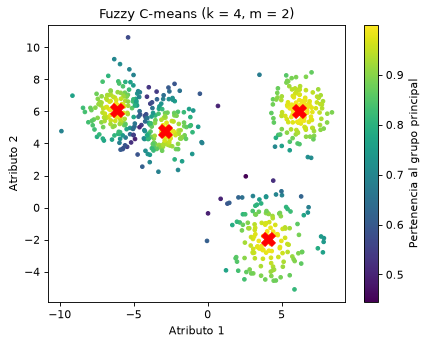

Puntos con pertenencia principal < 0,6 (ambiguos): 28 de 600
ARI (asignando cada punto a su grupo principal): 0.87


In [8]:
def fuzzy_cmeans(X, k, m=2.0, n_iter=100, tol=1e-5, seed=42):
    """Fuzzy C-means: devuelve la matriz de pertenencias U (n × k) y los centros."""
    U = np.random.default_rng(seed).dirichlet(np.ones(k), size=len(X))
    for _ in range(n_iter):
        pesos = U ** m
        centros = (pesos.T @ X) / pesos.sum(axis=0)[:, None]
        dist = np.fmax(cdist(X, centros), 1e-10)
        U_nueva = 1.0 / ((dist[:, :, None] / dist[:, None, :]) ** (2 / (m - 1))).sum(axis=2)
        if np.abs(U_nueva - U).max() < tol:
            break
        U = U_nueva
    return U_nueva, centros

U, centros_fcm = fuzzy_cmeans(X, k=4)
pertenencia_max = U.max(axis=1)

fig, ax = plt.subplots(figsize=(6, 4.5), dpi=80)
puntos = ax.scatter(X[:, 0], X[:, 1], c=pertenencia_max, cmap="viridis", s=10)
ax.scatter(*centros_fcm.T, c="red", marker="X", s=150)
fig.colorbar(puntos, label="Pertenencia al grupo principal")
ax.set_title("Fuzzy C-means (k = 4, m = 2)")
ax.set_xlabel("Atributo 1")
ax.set_ylabel("Atributo 2")
plt.show()

print(f"Puntos con pertenencia principal < 0,6 (ambiguos): {(pertenencia_max < 0.6).sum()} de {len(X)}")
print(f"ARI (asignando cada punto a su grupo principal): {adjusted_rand_score(y, U.argmax(axis=1)):.2f}")

Los puntos del interior de cada grupo tienen pertenencias cercanas a 1 (amarillo). Los de la frontera entre los dos grupos cercanos tienen pertenencias repartidas (azul-violeta). Esa información se pierde en k-means, que asigna igual de "seguro" un punto del centro que uno de la frontera. Asignando cada punto a su grupo principal, el resultado se parece al de k-means.

### 3.8. Muchos datos: mini-batch k-means y Canopy

Con 200.000 observaciones, **mini-batch k-means** actualiza los centroides con muestras pequeñas en cada iteración:

In [9]:
X_grande = rng.normal(size=(200_000, 10))
for modelo in [KMeans(n_clusters=8, n_init=3, random_state=42),
               MiniBatchKMeans(n_clusters=8, n_init=3, batch_size=2048, random_state=42)]:
    inicio = time.perf_counter()
    modelo.fit(X_grande)
    print(f"{type(modelo).__name__:16s} {time.perf_counter() - inicio:5.2f} s | inercia {modelo.inertia_:,.0f}")

KMeans            0.89 s | inercia 1,531,532


MiniBatchKMeans   0.25 s | inercia 1,537,895


Mini-batch es unas 3–4 veces más rápido, con una inercia menos de un 1 % mayor. Con millones de filas, la diferencia es la que hay entre poder o no poder agrupar.

**Canopy** tampoco está en scikit-learn. Su idea cabe en pocas líneas. Lo aplicamos a los 4 grupos sintéticos con dos pares de umbrales:

In [10]:
def canopy(X, t1, t2, seed=42):
    """Devuelve los índices de los centros de canopy (t1 > t2)."""
    rng_c = np.random.default_rng(seed)
    pendientes = np.arange(len(X))
    centros = []
    while len(pendientes) > 0:
        centro = rng_c.choice(pendientes)
        centros.append(centro)
        d = np.linalg.norm(X[pendientes] - X[centro], axis=1)  # distancia "barata"
        pendientes = pendientes[d >= t2]  # los muy cercanos ya no pueden ser centro
    return np.array(centros)

for t1, t2 in [(6, 4), (8, 5)]:
    print(f"T1 = {t1}, T2 = {t2}: {len(canopy(X, t1, t2))} canopies")

T1 = 6, T2 = 4: 9 canopies
T1 = 8, T2 = 5: 6 canopies


Salen 9 y 6 canopies para 4 grupos reales: cada grupo queda cubierto por varios canopies que se solapan, y el número depende mucho de $T_2$ (con un radio de retirada mayor salen menos). Canopy **no** estima $k$ con precisión ni sustituye a k-means. Su utilidad es otra: con millones de puntos, reduce las comparaciones, porque el algoritmo caro solo calcula distancias entre puntos que comparten canopy (definidos por $T_1$). En esta versión simplificada solo se calculan los centros.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Clase | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `KMeans` | `n_clusters` | Número de grupos $k$ | Elígelo con codo, silueta **y** conocimiento del dominio |
| | `init` | `"k-means++"` (por defecto) o `"random"` | Mantén k-means++ |
| | `n_init` | Nº de ejecuciones con semillas distintas | Con `"auto"` y k-means++ es **1**: pon 10 o más para resultados estables |
| | `random_state` | Semilla | Fíjala para reproducir resultados |
| | `max_iter`, `tol` | Límite de iteraciones y tolerancia | Los valores por defecto bastan casi siempre |
| `MiniBatchKMeans` | `batch_size` | Tamaño de las muestras | Más grande = más estable y más lento |
| `silhouette_score` | `metric`, `sample_size` | Distancia y submuestra | Con muchos datos, `sample_size` evita el coste $O(n^2)$ |
| Fuzzy C-means | `m` | Grado de difusión | 2 es lo habitual; más alto = pertenencias más repartidas |
| Canopy | $T_1 > T_2$ | Radios de pertenencia y de retirada | Dependen de la escala: estandariza antes |

### 4.2. Errores comunes

Varias de estas lecciones salen de un análisis real de k-means sobre tres conjuntos sintéticos: grupos esféricos, lunas y círculos concéntricos.

**1. Fiarse solo del método del codo.** En los grupos esféricos, el codo no permitía decidir entre $k = 3$ y $k = 4$. Se sugirió complementarlo con la silueta, pero no llegó a calcularse. En 3.3 se ve que la silueta tampoco resuelve siempre la duda: aquí elige $k = 3$ cuando hay 4 grupos reales, porque dos están muy juntos. Usa varias señales (codo, silueta, estabilidad entre semillas, interpretabilidad de los grupos) y decide con el objetivo del análisis en mente.

**2. Reutilizar la variable del caso anterior.** Al analizar el codo de los círculos, la celda (copiada de la de las lunas) imprimía y dibujaba la inercia **de las lunas**. La conclusión, "aparece lo mismo que en el ejemplo anterior", era literalmente cierta: era el mismo gráfico. Al copiar celdas para repetir un análisis, comprueba que cambian **todas** las variables. Mejor aún, encapsula el análisis en una función que reciba los datos como argumento:

In [11]:
# Mismo análisis, distintos datos: la función evita mezclar variables entre casos
def inercias_por_k(X_caso, valores=range(1, 7)):
    return [round(KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_caso).inertia_, 1) for k in valores]

X_lunas, _ = make_moons(n_samples=500, noise=0.06, random_state=42)
X_circ, _ = make_circles(n_samples=500, factor=0.45, noise=0.05, random_state=42)
print("Lunas:   ", inercias_por_k(X_lunas))
print("Círculos:", inercias_por_k(X_circ))

Lunas:    [503.2, 203.5, 135.9, 87.9, 65.7, 45.2]
Círculos: [301.2, 193.8, 120.6, 87.8, 71.0, 61.7]


Las dos curvas son distintas. Pero en ninguna de las dos el codo apunta a los 2 grupos reales, porque la inercia de k-means supone grupos compactos.

**3. Usar k-means con formas no convexas.** En aquel análisis se concluyó bien que k-means no puede separar lunas ni círculos, porque solo encuentra grupos convexos, separables por fronteras rectas (3.4). En esos casos, el problema no se arregla eligiendo mejor $k$: hay que cambiar de algoritmo ([densidad](06-clustering-densidad.ipynb) o [enlace simple](04-clustering-jerarquico.ipynb)).

**4. Una sola inicialización.** Con las versiones actuales de scikit-learn, `KMeans(n_clusters=k)` sin `n_init` hace **una única** ejecución con k-means++. Suele bastar, pero no siempre. Con inicialización aleatoria, la mitad de las ejecuciones acaba en un mínimo local malo (3.2). Pon `n_init=10` (o más) y fija `random_state`.

**5. No escalar.** En *wine*, el ARI pasa de 0,37 a 0,90 solo por estandarizar (3.5).

**6. Interpretar el número de grupo como una clase.** Las etiquetas de k-means son arbitrarias: el "grupo 0" de una ejecución puede ser el "grupo 2" de otra, y no tienen por qué coincidir con las etiquetas reales. En aquel análisis se advirtió correctamente que "los colores no tienen relación". Para comparar con etiquetas reales se usa el **ARI**, que no depende de la numeración, y no la exactitud.

**7. Aplicar k-means a variables categóricas.** La media de columnas one-hot no es una categoría, y la distancia euclídea sobre ellas tiene poco sentido. Para datos binarios o mixtos, usa k-medoids con Jaccard o Gower (3.6), *k-modes*, o clustering jerárquico con la distancia adecuada.

## 5. Comparación con métodos relacionados

| Método | Centro | Distancia | Robusto a atípicos | Formas | Coste | Cuándo usarlo |
|---|---|---|---|---|---|---|
| **k-means** | Media | Euclídea | No | Convexas, esféricas | Muy bajo | Primera opción con datos numéricos escalados |
| **k-medians** | Mediana | Manhattan | Más | Convexas | Bajo | Atípicos o distribuciones asimétricas |
| **k-medoids** | Punto real | Cualquiera | Sí | Convexas | Alto ($O(n^2)$ distancias) | Distancias no euclídeas; centros interpretables |
| **Fuzzy C-means** | Media ponderada | Euclídea | No | Convexas | Medio | Grupos solapados; interesa el grado de pertenencia |
| **Mini-batch k-means** | Media | Euclídea | No | Convexas | Muy bajo | Muchos datos (cientos de miles o más) |
| **Canopy** + k-means | — | Barata + euclídea | — | — | Reduce comparaciones | Preclustering de conjuntos enormes |
| [Jerárquico](04-clustering-jerarquico.ipynb) | — | Cualquiera (Ward: euclídea) | Según enlace | Según enlace | Alto | Pocos datos; interesa la jerarquía |
| [DBSCAN / HDBSCAN](06-clustering-densidad.ipynb) | — | Cualquiera | Sí (marca ruido) | Arbitrarias | Medio | Formas raras, ruido, $k$ desconocido |

## 6. Referencias

### Fuentes

- scikit-learn: [*Clustering*](https://scikit-learn.org/stable/modules/clustering.html) (k-means, mini-batch k-means, bisecting k-means, silueta, índice de Rand ajustado) y [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) (`init`, `n_init`, `inertia_`).
- SciPy: [`scipy.spatial.distance.cdist`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html), usada en las implementaciones de k-medoids y fuzzy C-means.
- Datasets: [wine en scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html) (repositorio UCI) y generadores sintéticos `make_blobs`, `make_moons` y `make_circles`.

### Para saber más

- Arthur, D. y Vassilvitskii, S. (2007). *k-means++: The Advantages of Careful Seeding*. En *Proceedings of the 18th Annual ACM-SIAM Symposium on Discrete Algorithms (SODA)*, 1027–1035. La inicialización que usa scikit-learn por defecto.
- Jain, A. K. (2010). *Data clustering: 50 years beyond K-means*. Pattern Recognition Letters, 31(8), 651–666. Revisión de k-means, sus limitaciones y sus alternativas.